,[run number],infectiousness,[step],ticks
,<int>,<int>,<int>,<int>
1,5,10,21,21
2,2,10,23,23
3,4,10,36,36
4,8,10,40,40
5,10,10,25,25
6,7,10,40,40


[1] "[run number]"   "infectiousness" "[step]"         "ticks"

Rows: 180
Columns: 4
$ `[run number]` <int> 5, 2, 4, 8, 10, 7, 3, 11, 9, 6, 12, 14, 17, 18, 15, 20,…
$ infectiousness <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,…
$ `[step]`       <int> 21, 23, 36, 40, 25, 40, 35, 32, 38, 64, 49, 40, 40, 49,…
$ ticks          <int> 21, 23, 36, 40, 25, 40, 35, 32, 38, 64, 49, 40, 40, 49,…


,corrida,parametro,paso,resultado_final
,<int>,<dbl>,<dbl>,<dbl>
1,5,10,21,21
2,2,10,23,23
3,4,10,36,36
4,8,10,40,40
5,10,10,25,25
6,7,10,40,40


,parametro,resultado_final
,<dbl>,<dbl>
1,10,21
2,10,23
3,10,36
4,10,40
5,10,25
6,10,40


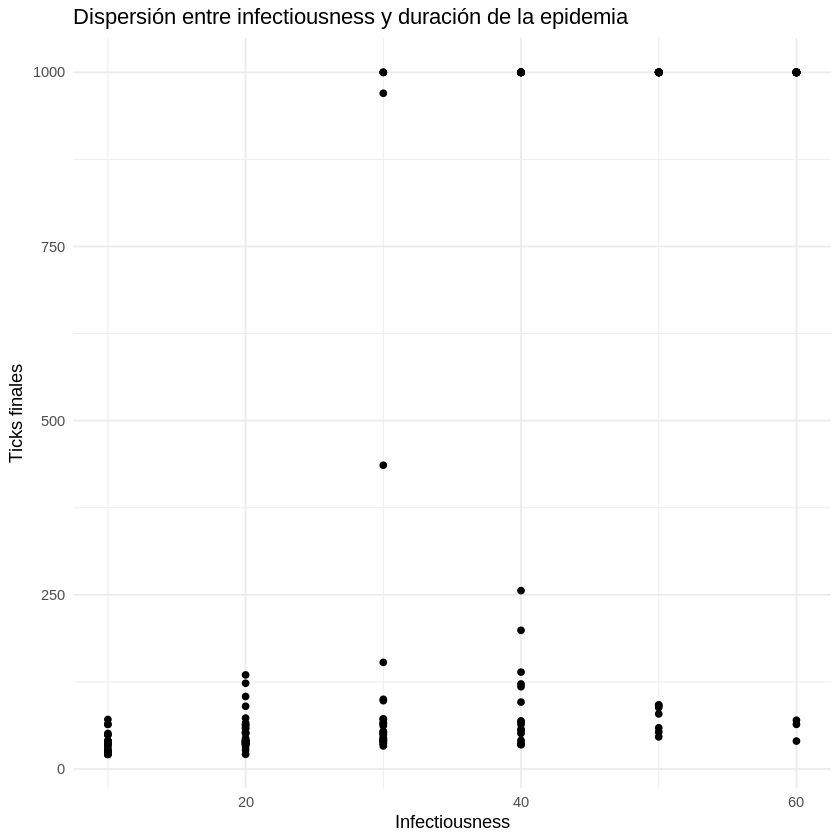

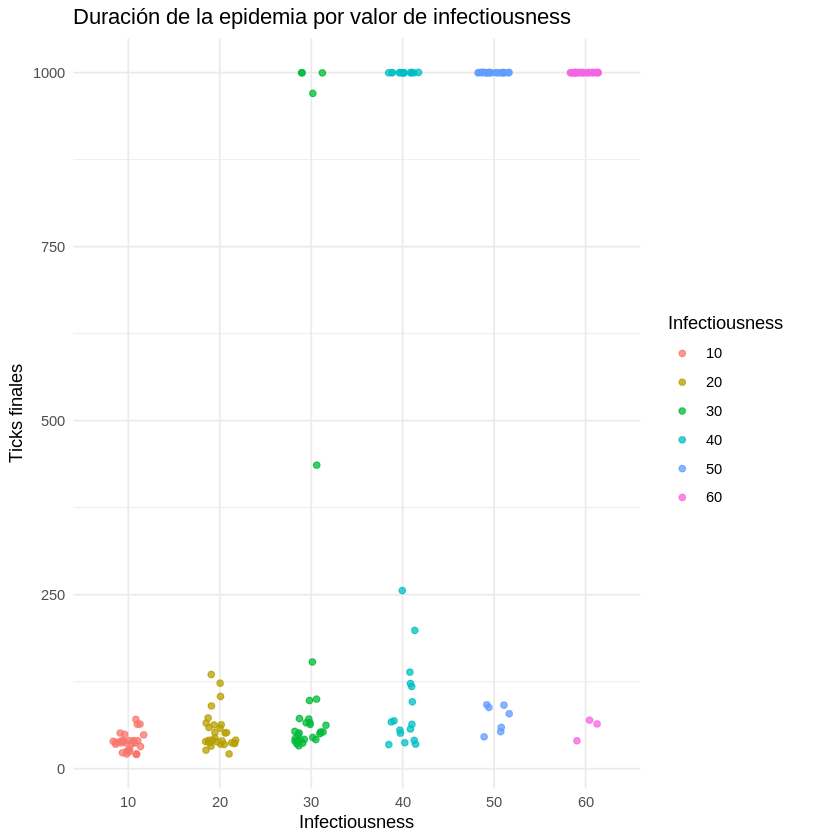

parametro,repeticiones,promedio_ticks,mediana_ticks,minimo_ticks,maximo_ticks,desviacion_ticks
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,30,37.63333,37.5,21,71,12.98934
20,30,53.63333,41.0,21,135,27.26812
30,30,195.60000,53.5,33,1000,326.17243
40,30,514.70000,227.5,35,1000,463.96791
50,30,783.60000,1000.0,46,1000,399.06214
60,30,905.80000,1000.0,40,1000,287.46135



INTERPRETACION ANALISIS FINAL:
En el analisis final se comparo el parametro infectiousness con la duracion de la epidemia medida en ticks.
La grafica permite observar como cambia el tiempo final de la simulacion cuando aumenta la capacidad de contagio del virus.
Si los valores altos de infectiousness presentan mayores valores de ticks, esto indica que la epidemia tiende a durar mas tiempo cuando la enfermedad tiene mayor facilidad para transmitirse.
La dispersion entre corridas con el mismo parametro muestra variabilidad del modelo, posiblemente causada por el comportamiento aleatorio de los agentes, sus posiciones iniciales y sus interacciones.
El boxplot permite comparar la mediana, la variabilidad y posibles valores atipicos.


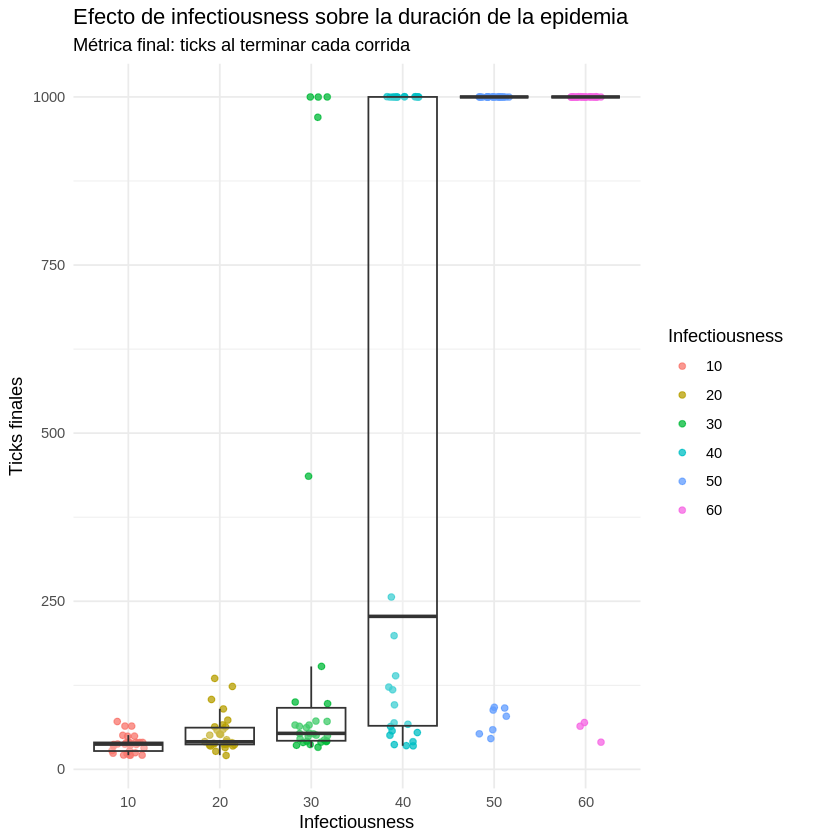

In [2]:
# ============================================================
# ANALISIS FINAL
# Modelo: Virus.nlogox
# Parametro independiente: infectiousness
# Metrica final: ticks
# Archivo: modelo_virus_infectiousness_final.csv
# ============================================================


# ============================================================
# 1. Instalar y cargar librerias
# ============================================================

if (!requireNamespace("tidyverse", quietly = TRUE)) {
  install.packages("tidyverse")
}

library(tidyverse)


# ============================================================
# 2. Cargar CSV final desde GitHub Raw
# ============================================================

url_final <- "https://raw.githubusercontent.com/pulag00/An-lisis-de-datos-de-NetLogo-con-BehaviorSpace/main/modelo_virus_infectiousness_final.csv"


# ============================================================
# 3. Funcion para leer archivos CSV exportados por BehaviorSpace
# ============================================================

leer_behaviorspace <- function(url_o_ruta, skip = 6) {
  lineas <- readLines(url_o_ruta, warn = FALSE, encoding = "UTF-8")

  lineas <- lineas[-seq_len(skip)]

  lineas <- ifelse(
    startsWith(lineas, '"') & endsWith(lineas, '"'),
    substr(lineas, 2, nchar(lineas) - 1),
    lineas
  )

  lineas <- gsub('""', '"', lineas, fixed = TRUE)

  read.csv(
    text = paste(lineas, collapse = "\n"),
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
}


# ============================================================
# 4. Leer datos finales
# ============================================================

data_final_raw <- leer_behaviorspace(url_final)


# ============================================================
# 5. Inspeccionar columnas
# ============================================================

head(data_final_raw)
names(data_final_raw)
glimpse(data_final_raw)


# ============================================================
# 6. Renombrar columnas del CSV final
# ============================================================
# Columnas reales esperadas:
# [run number]
# infectiousness
# [step]
# ticks

final <- data_final_raw %>%
  transmute(
    corrida = as.integer(`[run number]`),
    parametro = as.numeric(infectiousness),
    paso = as.numeric(`[step]`),
    resultado_final = as.numeric(ticks)
  )

head(final)


# ============================================================
# 7. Seleccionar parametro y metrica final
# ============================================================

datos_finales <- final %>%
  select(parametro, resultado_final)

head(datos_finales)


# ============================================================
# 8. Grafica de dispersion simple
# ============================================================

grafica_dispersion <- datos_finales %>%
  ggplot(aes(x = parametro, y = resultado_final)) +
  geom_point() +
  labs(
    title = "Dispersión entre infectiousness y duración de la epidemia",
    x = "Infectiousness",
    y = "Ticks finales"
  ) +
  theme_minimal()

grafica_dispersion


# ============================================================
# 9. Grafica con jitter y color por parametro
# ============================================================

grafica_jitter <- datos_finales %>%
  ggplot(aes(x = factor(parametro), y = resultado_final)) +
  geom_jitter(
    aes(color = factor(parametro)),
    width = 0.18,
    alpha = 0.75
  ) +
  labs(
    title = "Duración de la epidemia por valor de infectiousness",
    x = "Infectiousness",
    y = "Ticks finales",
    color = "Infectiousness"
  ) +
  theme_minimal()

grafica_jitter


# ============================================================
# 10. Boxplot agrupado por parametro
# ============================================================

grafica_final <- datos_finales %>%
  ggplot(aes(x = factor(parametro), y = resultado_final)) +
  geom_jitter(
    aes(color = factor(parametro)),
    width = 0.18,
    alpha = 0.75
  ) +
  geom_boxplot(
    aes(group = parametro),
    alpha = 0.25,
    outlier.shape = NA
  ) +
  labs(
    title = "Efecto de infectiousness sobre la duración de la epidemia",
    subtitle = "Métrica final: ticks al terminar cada corrida",
    x = "Infectiousness",
    y = "Ticks finales",
    color = "Infectiousness"
  ) +
  theme_minimal()

grafica_final


# ============================================================
# 11. Tabla resumen del analisis final
# ============================================================

resumen_final <- datos_finales %>%
  group_by(parametro) %>%
  summarise(
    repeticiones = n(),
    promedio_ticks = mean(resultado_final, na.rm = TRUE),
    mediana_ticks = median(resultado_final, na.rm = TRUE),
    minimo_ticks = min(resultado_final, na.rm = TRUE),
    maximo_ticks = max(resultado_final, na.rm = TRUE),
    desviacion_ticks = sd(resultado_final, na.rm = TRUE),
    .groups = "drop"
  )

resumen_final


# ============================================================
# 12. Exportar grafica y tabla
# ============================================================

ggsave(
  filename = "grafica_final_infectiousness_ticks.png",
  plot = grafica_final,
  width = 9,
  height = 5,
  dpi = 300
)

write.csv(
  resumen_final,
  "resumen_final_ticks.csv",
  row.names = FALSE
)


# ============================================================
# 13. Interpretacion base
# ============================================================

cat("\nINTERPRETACION ANALISIS FINAL:\n")
cat("En el analisis final se comparo el parametro infectiousness con la duracion de la epidemia medida en ticks.\n")
cat("La grafica permite observar como cambia el tiempo final de la simulacion cuando aumenta la capacidad de contagio del virus.\n")
cat("Si los valores altos de infectiousness presentan mayores valores de ticks, esto indica que la epidemia tiende a durar mas tiempo cuando la enfermedad tiene mayor facilidad para transmitirse.\n")
cat("La dispersion entre corridas con el mismo parametro muestra variabilidad del modelo, posiblemente causada por el comportamiento aleatorio de los agentes, sus posiciones iniciales y sus interacciones.\n")
cat("El boxplot permite comparar la mediana, la variabilidad y posibles valores atipicos.\n")

,[run number],infectiousness,[step],count turtles with [sick?]
,<int>,<int>,<int>,<int>
1,5,10,0,10
2,5,10,1,10
3,5,10,2,11
4,5,10,3,11
5,5,10,4,11
6,5,10,5,11


[1] "[run number]"               "infectiousness"            
[3] "[step]"                     "count turtles with [sick?]"

Rows: 14,320
Columns: 4
$ `[run number]`               <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,…
$ infectiousness               <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 1…
$ `[step]`                     <int> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,…
$ `count turtles with [sick?]` <int> 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 1…


,corrida,parametro,tiempo,valor_temporal
,<int>,<dbl>,<dbl>,<dbl>
1,5,10,0,10
2,5,10,1,10
3,5,10,2,11
4,5,10,3,11
5,5,10,4,11
6,5,10,5,11


,parametro,tiempo,valor_temporal
,<dbl>,<dbl>,<dbl>
1,10,0,10
2,10,1,10
3,10,2,11
4,10,3,11
5,10,4,11
6,10,5,11


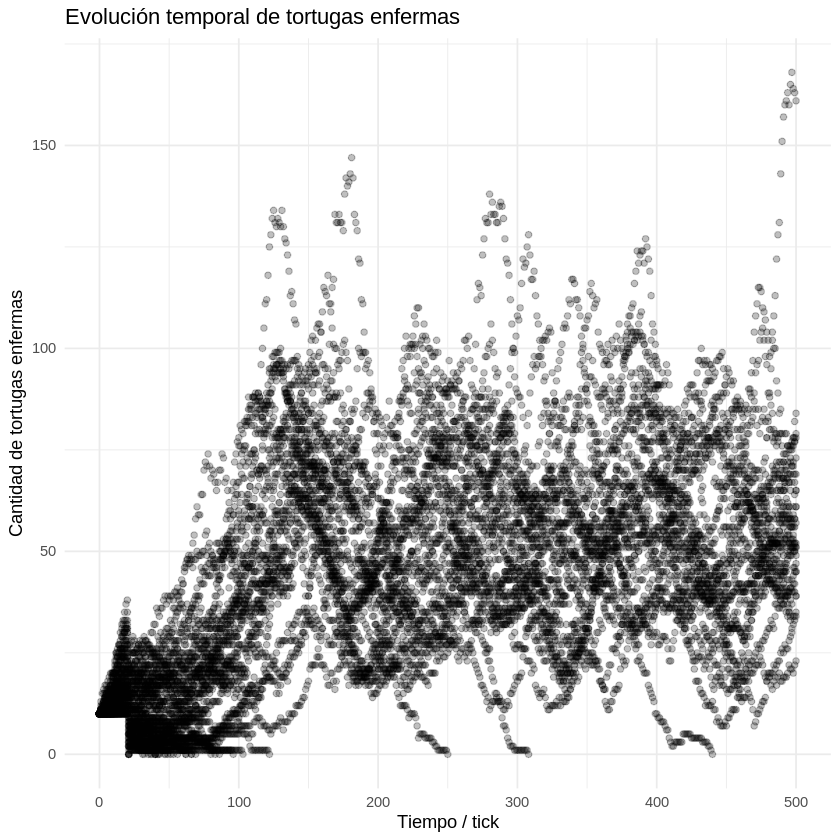

parametro,tiempo,promedio,mediana,desviacion,repeticiones
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
10,0,10.0,10,0.0000000,10
10,1,10.0,10,0.0000000,10
10,2,10.2,10,0.4216370,10
10,3,10.3,10,0.6749486,10
10,4,10.4,10,0.9660918,10
10,5,10.4,10,0.9660918,10


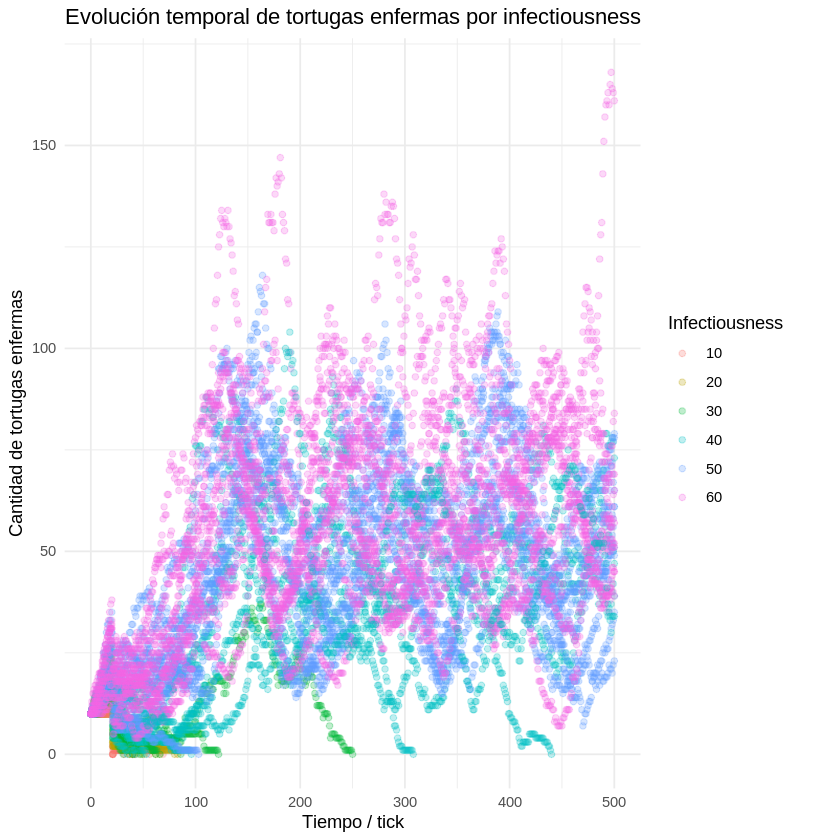

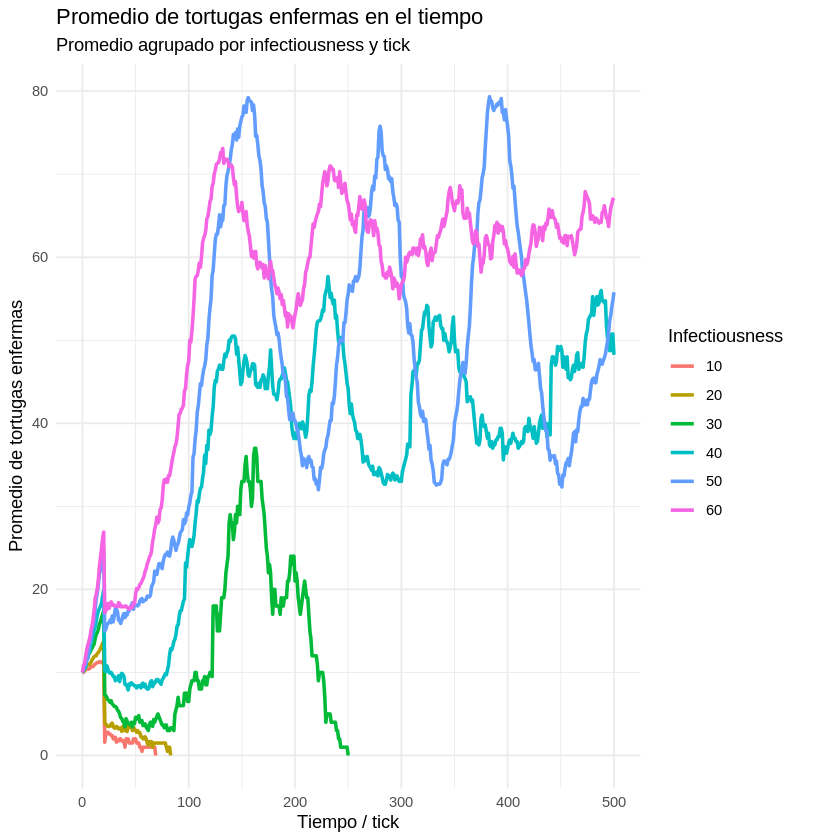

parametro,tiempo,promedio,mediana,desviacion,repeticiones
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
10,20,11.50000,10.5,2.460804,10
20,20,13.70000,13.5,1.888562,10
30,162,37.00000,37.0,NA,1
40,231,57.66667,56.5,26.530486,6
50,383,79.33333,80.0,16.807736,9
60,132,73.10000,78.0,31.455259,10



INTERPRETACION ANALISIS EVOLUTIVO:
En el analisis evolutivo se estudio como cambia la cantidad de tortugas enfermas a lo largo del tiempo para diferentes valores de infectiousness.
La variable temporal usada fue count turtles with [sick?], registrada en cada tick de la simulacion.
La grafica de puntos permite observar la dispersion de los datos en cada corrida.
Al agrupar por parametro y tiempo se calculo el promedio de tortugas enfermas para construir curvas de evolucion temporal.
Si los valores altos de infectiousness presentan picos mas altos, esto indica que una mayor capacidad de contagio produce una propagacion mas intensa de la enfermedad.
Si las curvas se mantienen activas durante mas ticks, esto sugiere que la epidemia tarda mas tiempo en desaparecer.
La visualizacion con facet_wrap permite comparar cada valor de infectiousness por separado.


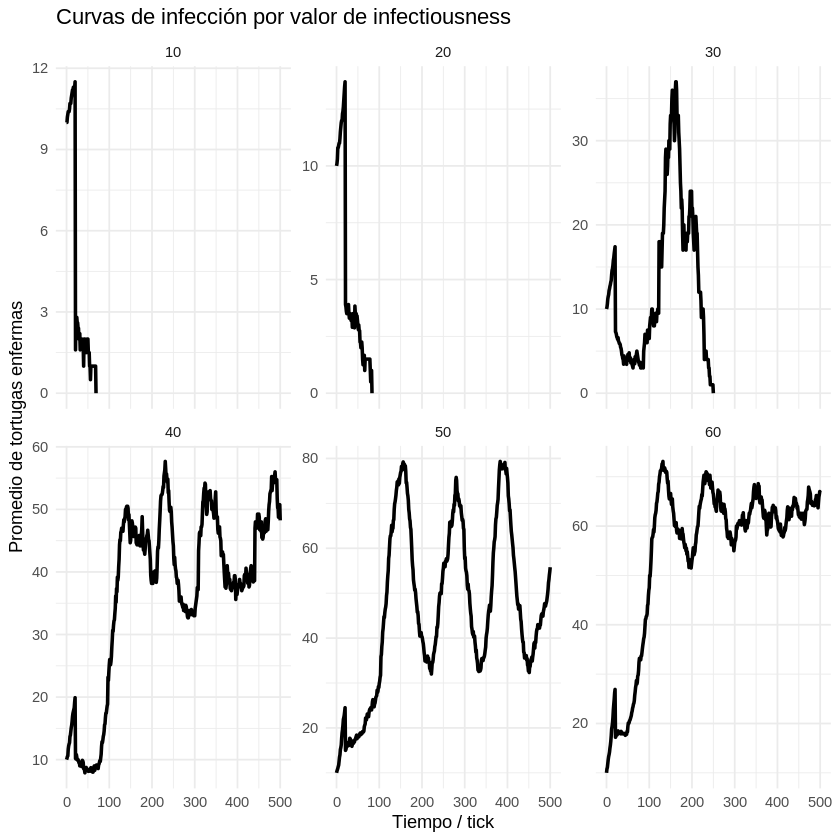

In [3]:
# ============================================================
# ANALISIS EVOLUTIVO
# Modelo: Virus.nlogox
# Parametro independiente: infectiousness
# Metrica temporal: count turtles with [sick?]
# Archivo: modelo_virus_infectiousness_evolucion.csv
# ============================================================


# ============================================================
# 1. Instalar y cargar librerias
# ============================================================

if (!requireNamespace("tidyverse", quietly = TRUE)) {
  install.packages("tidyverse")
}

library(tidyverse)


# ============================================================
# 2. Cargar CSV evolutivo desde GitHub Raw
# ============================================================

url_evol <- "https://raw.githubusercontent.com/pulag00/An-lisis-de-datos-de-NetLogo-con-BehaviorSpace/main/modelo_virus_infectiousness_evolucion.csv"


# ============================================================
# 3. Funcion para leer archivos CSV exportados por BehaviorSpace
# ============================================================

leer_behaviorspace <- function(url_o_ruta, skip = 6) {
  lineas <- readLines(url_o_ruta, warn = FALSE, encoding = "UTF-8")

  lineas <- lineas[-seq_len(skip)]

  lineas <- ifelse(
    startsWith(lineas, '"') & endsWith(lineas, '"'),
    substr(lineas, 2, nchar(lineas) - 1),
    lineas
  )

  lineas <- gsub('""', '"', lineas, fixed = TRUE)

  read.csv(
    text = paste(lineas, collapse = "\n"),
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
}


# ============================================================
# 4. Leer datos evolutivos
# ============================================================

data_evol_raw <- leer_behaviorspace(url_evol)


# ============================================================
# 5. Inspeccionar columnas
# ============================================================

head(data_evol_raw)
names(data_evol_raw)
glimpse(data_evol_raw)


# ============================================================
# 6. Renombrar columnas del CSV evolutivo
# ============================================================
# Columnas reales esperadas:
# [run number]
# infectiousness
# [step]
# count turtles with [sick?]

evol <- data_evol_raw %>%
  transmute(
    corrida = as.integer(`[run number]`),
    parametro = as.numeric(infectiousness),
    tiempo = as.numeric(`[step]`),
    valor_temporal = as.numeric(`count turtles with [sick?]`)
  )

head(evol)


# ============================================================
# 7. Seleccionar columnas relevantes
# ============================================================

datos_evolutivos <- evol %>%
  select(parametro, tiempo, valor_temporal)

head(datos_evolutivos)


# ============================================================
# 8. Grafica tiempo contra valor temporal
# ============================================================

grafica_evol_puntos <- datos_evolutivos %>%
  ggplot(aes(x = tiempo, y = valor_temporal)) +
  geom_point(alpha = 0.25) +
  labs(
    title = "Evolución temporal de tortugas enfermas",
    x = "Tiempo / tick",
    y = "Cantidad de tortugas enfermas"
  ) +
  theme_minimal()

grafica_evol_puntos


# ============================================================
# 9. Grafica con color por parametro
# ============================================================

grafica_evol_color <- datos_evolutivos %>%
  ggplot(aes(
    x = tiempo,
    y = valor_temporal,
    color = factor(parametro)
  )) +
  geom_point(alpha = 0.25) +
  labs(
    title = "Evolución temporal de tortugas enfermas por infectiousness",
    x = "Tiempo / tick",
    y = "Cantidad de tortugas enfermas",
    color = "Infectiousness"
  ) +
  theme_minimal()

grafica_evol_color


# ============================================================
# 10. Agrupar por parametro y tiempo
# ============================================================

resumen_evol <- datos_evolutivos %>%
  group_by(parametro, tiempo) %>%
  summarise(
    promedio = mean(valor_temporal, na.rm = TRUE),
    mediana = median(valor_temporal, na.rm = TRUE),
    desviacion = sd(valor_temporal, na.rm = TRUE),
    repeticiones = n(),
    .groups = "drop"
  )

head(resumen_evol)


# ============================================================
# 11. Graficar lineas de evolucion temporal
# ============================================================

grafica_evol_lineas <- resumen_evol %>%
  ggplot(aes(
    x = tiempo,
    y = promedio,
    color = factor(parametro)
  )) +
  geom_line(linewidth = 1) +
  labs(
    title = "Promedio de tortugas enfermas en el tiempo",
    subtitle = "Promedio agrupado por infectiousness y tick",
    x = "Tiempo / tick",
    y = "Promedio de tortugas enfermas",
    color = "Infectiousness"
  ) +
  theme_minimal()

grafica_evol_lineas


# ============================================================
# 12. Facetas por valor del parametro
# ============================================================

grafica_evol_facetas <- resumen_evol %>%
  ggplot(aes(x = tiempo, y = promedio)) +
  geom_line(linewidth = 1) +
  facet_wrap(~ parametro, scales = "free_y") +
  labs(
    title = "Curvas de infección por valor de infectiousness",
    x = "Tiempo / tick",
    y = "Promedio de tortugas enfermas"
  ) +
  theme_minimal()

grafica_evol_facetas


# ============================================================
# 13. Identificar pico promedio de infectados por grupo
# ============================================================

picos_infeccion <- resumen_evol %>%
  group_by(parametro) %>%
  slice_max(
    order_by = promedio,
    n = 1,
    with_ties = FALSE
  ) %>%
  ungroup() %>%
  arrange(parametro)

picos_infeccion


# ============================================================
# 14. Exportar graficas y tablas
# ============================================================

ggsave(
  filename = "grafica_evolutiva_puntos.png",
  plot = grafica_evol_color,
  width = 9,
  height = 5,
  dpi = 300
)

ggsave(
  filename = "grafica_evolutiva_lineas.png",
  plot = grafica_evol_lineas,
  width = 9,
  height = 5,
  dpi = 300
)

ggsave(
  filename = "grafica_evolutiva_facetas.png",
  plot = grafica_evol_facetas,
  width = 10,
  height = 6,
  dpi = 300
)

write.csv(
  resumen_evol,
  "resumen_evolutivo_promedios.csv",
  row.names = FALSE
)

write.csv(
  picos_infeccion,
  "picos_promedio_infectados.csv",
  row.names = FALSE
)


# ============================================================
# 15. Interpretacion base
# ============================================================

cat("\nINTERPRETACION ANALISIS EVOLUTIVO:\n")
cat("En el analisis evolutivo se estudio como cambia la cantidad de tortugas enfermas a lo largo del tiempo para diferentes valores de infectiousness.\n")
cat("La variable temporal usada fue count turtles with [sick?], registrada en cada tick de la simulacion.\n")
cat("La grafica de puntos permite observar la dispersion de los datos en cada corrida.\n")
cat("Al agrupar por parametro y tiempo se calculo el promedio de tortugas enfermas para construir curvas de evolucion temporal.\n")
cat("Si los valores altos de infectiousness presentan picos mas altos, esto indica que una mayor capacidad de contagio produce una propagacion mas intensa de la enfermedad.\n")
cat("Si las curvas se mantienen activas durante mas ticks, esto sugiere que la epidemia tarda mas tiempo en desaparecer.\n")
cat("La visualizacion con facet_wrap permite comparar cada valor de infectiousness por separado.\n")